## Importer des données

Pandas est une librairie Python qui permet de manipuler des données numériques présentées sous la forme de tableau, comme c'est le cas ici pour ce rôle (livre de passages et hommes d'équipages) qui comportent les noms, sex, âge et pour les passages classe occupée)

In [3]:
pip -r install requirements.txt


Usage:   
  /home/dbelveze/.conda/envs/environnement/bin/python -m pip <command> [options]

no such option: -r
Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd

La librairie Numpy permet de réaliser des manipulations de tablea
ux à N dimensions. La liste des fonctions du package Numpy est disponible en ligne http://docs.scipy.org/doc/numpy/reference/routines.html

In [5]:
import numpy as np

In [6]:
import matplotlib.pyplot as plt

MATLAB, alias matplotlib est également une librairie Python qui permet de faire des représentations graphiques de données

In [7]:
df = pd.read_csv("data/raw/titanic.csv") # charge le jeu de données CSV "titanic", ce jeu de données fournit notre dataframe (variable df)
df.head(6) # affiche les 6 premiers enregistrements du dataframe


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q


In [8]:
df.info() # affiche des infos sur le contenu du tableau

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## nettoyer les données

voir guide : 
https://colab.research.google.com/github/hkhdair/DAS9800-data-analytics-python/blob/main/titanic_eda_guide.ipynb#scrollTo=7EvKdSkcy9qB

In [9]:
df = df.drop(['Cabin', 'Parch'], axis=1) # supprime les colonnes Cabin et Parch où il y a trop de valeurs nulles
df.head() # vérifie le résultat de cette suppression

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,373450,8.0500,S


## âge entre 0 et 1 ans
https://moodle.univ-tln.fr/pluginfile.php/564223/mod_resource/content/8/_site/M55-3.html
trouver l'homme le plus âgé : 

In [10]:
df_men = df.loc[df['Sex'] == "male"] # définit une variable df_men qui va sélectionner dans le tableau de données df tous les items qui ont la valeur male dans la colonne Se
# pour voir le résultat de cette manipulation on peut entrer :
#df_men.head(7)
oldest = df_men['Age'].max() # définit une variable qui dans df_men à la colonne Age sélectionne la valeur maximale
# pour afficher cette valeur : 
print(oldest)

80.0


In [11]:
print(type(df['Age']))
# affiche le type de df[âge] ; il s'agit d'une série de nombres      

<class 'pandas.core.series.Series'>


In [12]:
type("Age")
# affiche le type de la variable 'Age', il s'agit d'une chaîne de caractères.

str

In [13]:
moyenne_age = df["Age"].mean() # moyenne d'âge des passagers du Titanic
moyenne_age_hommes = df_men["Age"].mean()
print(moyenne_age)
print(moyenne_age_hommes)

29.69911764705882
30.72664459161148


In [14]:
df_three_class = df.loc[df['Pclass'] == 3]  
three_class_survivors = df_three_class['Survived'] == 1
print(three_class_survivors)

0      False
2       True
4      False
5      False
7      False
       ...  
882    False
884    False
885    False
888    False
890    False
Name: Survived, Length: 491, dtype: bool


In [15]:
df_three_class = df.loc[df['Pclass'] == 3]  
three_class_survivors = df_three_class.query('Survived == 1')[['Name','Survived']]
print(three_class_survivors)

                                                  Name  Survived
2                               Heikkinen, Miss. Laina         1
8    Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)         1
10                     Sandstrom, Miss. Marguerite Rut         1
19                             Masselmani, Mrs. Fatima         1
22                         McGowan, Miss. Anna "Annie"         1
..                                                 ...       ...
838                                    Chip, Mr. Chang         1
855                         Aks, Mrs. Sam (Leah Rosen)         1
858              Baclini, Mrs. Solomon (Latifa Qurban)         1
869                    Johnson, Master. Harold Theodor         1
875                   Najib, Miss. Adele Kiamie "Jane"         1

[119 rows x 2 columns]


In [16]:
three_class_survivors_count = three_class_survivors.sum()
print(three_class_survivors_count)

Name        Heikkinen, Miss. LainaJohnson, Mrs. Oscar W (E...
Survived                                                  119
dtype: object


In [17]:
three_class_survivors.to_csv('data/processed/three_class_survivors.csv', index=False)

In [18]:
df.Pclass.value_counts() #nombre des passagers dans chaque classe


Pclass
3    491
1    216
2    184
Name: count, dtype: int64

# réaliser des visualisations du jeu de données

<Axes: ylabel='count'>

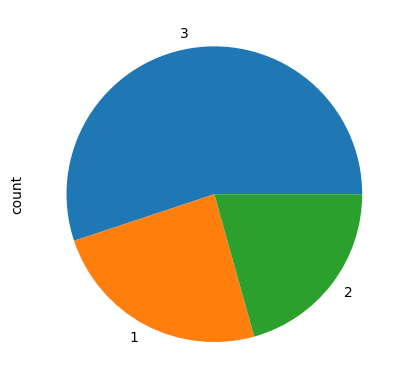

In [19]:
df.Pclass.value_counts().plot.pie()


In [20]:
grouped_data = df.groupby(['Pclass', 'Survived']).size().unstack()
print(grouped_data)

Survived    0    1
Pclass            
1          80  136
2          97   87
3         372  119


In [21]:
Pclass = sorted(df['Pclass'].unique())
print(Pclass)

[np.int64(1), np.int64(2), np.int64(3)]


In [22]:
x = np.arange(len(Pclass))  # emplacement de chaque valeur de Pclass dans le dataframe, la première (1) occupe l'emplacement 0
# une liste dans Python commence par défaut à l'emplacement 0, la classe "2" occupe l'emplacement 1, etc.
print(x)

[0 1 2]


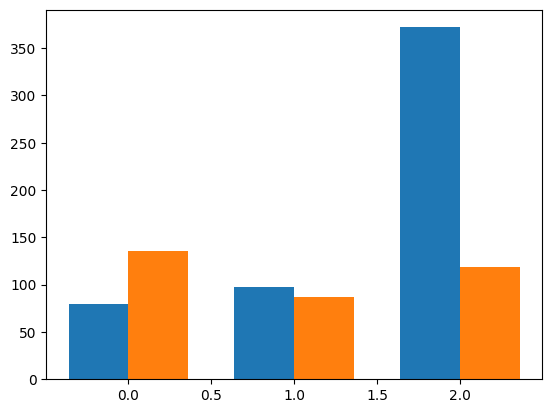

In [23]:
fig1, ax = plt.subplots() # crée une figure (nom = fig) qui comporte une sous-figure (nom = ax)
width = 0.36  # définit la largeur du groupe de barres
# attention aux nombres décimaux dans Python : on utilise des points, pas des virgules (pour ne pas créer de tuple = liste fermée de deux (ou plus) valeurs)
# cette largeur divisée par deux (width/2) définit la largeur d'une barre. 
# La première barre de gauche occupera x (par exemple 0) - width/2, c'est à dire l'espace qu'il y a entre 0 et -0,18
rects1 = ax.bar(x - width/2, grouped_data[0], width) #assigne à la barre de gauche la valeur 0
rects2 = ax.bar(x + width/2, grouped_data[1], width) # assigne à la barre de droite la valeur 1
plt.show(fig1) # affiche le graphique "fig1"

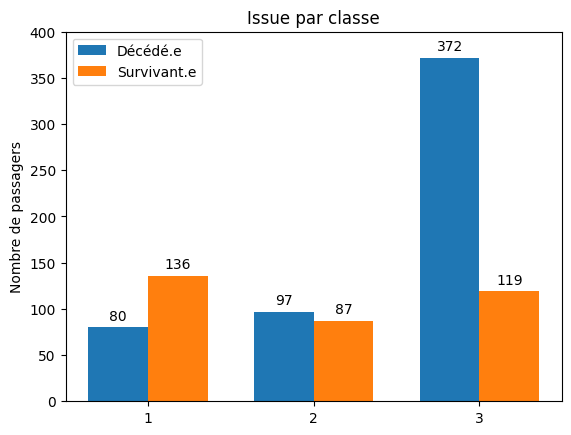

In [24]:
fig2, ax = plt.subplots()
# crée une figure (nom = fig) qui comporte une sous-figure (nom = ax)
width = 0.36
rects1 = ax.bar(x - width/2, grouped_data[0], width, label='Décédé.e')
rects2 = ax.bar(x + width/2, grouped_data[1], width, label='Survivant.e')
# Cette sous-figure est constituée pour chaque valeur de Pclass dans GroupData (x= 1,2,3) de 2 barres
# l'une avant la graduation correspondant à la valeur x (à gauche), l'autre après (à droite)

# on rajoute à présent les éléments de la légende
ax.set_ylabel('Nombre de passagers') # le titre de l'axe y
ax.set_title('Issue par classe') # le titre de ax
ax.set_xticks(x) 
ax.set_xticklabels(Pclass) # reprend dans l'axe x les valeurs de Pclass
ax.legend() # affiche la légende

ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)
# affiche les valeurs en haut de chaque bar (avec un espacement de 3 points). Le point est une valeur typographique qui 
# contrairement au pixel n'est pas liée à la résolution de l'écran. Par défaut (si pas de valeur entrée) cette valeur est de 4
ax.set_ylim(0, 400)# pour ne pas écraser la figure au dessus de 372 fait aller l'axe y jusqu'à la valeur 400
plt.show(fig2) # affiche le graphique "fig2"

une librairie Python permet d'épargner des lignes de code : seaborn. Seaborn permet d'entrer dans la composition du graphe un vecteur au lieu d'une valeur (un vecteur est constitué de plusieurs valeurs différentes). Ainsi dans le code ci-dessous, 'hue' permet d'entrer les différentes valeurs possibles de Survived, à savoir 0 ou 1. 

In [26]:
import seaborn as sns # on mobilise seaborn

ça peut sembler pratique d'ajouter une librairie supplémentaire pour réduire les lignes de code, mais cela comporte aussi des risques. 
Plus le code fait appel à un grand nombre de librairies et plus il est fragile sur le temps long. La persistance de certaines librairies n'est due qu'à la motivation de quelques personnes qui les maintiennent à titre bénévole. Cet écosystème est fragile. L'usage d'une librairie peu soutenue peut nuire à l'exécution d'un code source tout entier. 

In [ ]:
df['Survie'] = df['Survived'].map({0: 'Décédé.e', 1: 'Survivant.e'})
# la ligne du dessus fait un lien entre la valeur 0 de deceased et le terme "Décédé.e", pareil pour "Survivant.e"
# ceci afin que la légende n'arbore pas 0 ou 1 mais "Décédé.e" ou "Survivant.e"
fig3 = sns.countplot(x='Pclass', hue='Survie', data=df) #hue pour introduire un vecteur.
plt.title("Survie en fonction de la classe occupée")
plt.show(fig3)

Note: you may need to restart the kernel to use updated packages.
